# Visualizing an `ItemGraph` with ArcGIS Knowledge

Constructing an [`ItemGraph`](/python/latest/api-reference/arcgis.apps.itemgraph.html#itemgraph) can give us a lot of valuable information- the question then becomes, how can we best use it? Though analyzing our graphs purely in Python is possible, combining our graphs with the added capabilities of [ArcGIS Knowledge](https://doc.esri.com/en/arcgis-enterprise/latest/plan/additional-server-deployment.html?pivots=os-windows#AEE) allows us to take our analysis to the next level and easily visualize complex dependency structures.

For customers with access to an ArcGIS Enterprise with ArcGIS Knowledge Server enabled, version 2.4.3 of the ArcGIS API for Python introduces a handy tool- the [`ItemGraph.to_knowledge_graph()`](/python/latest/api-reference/arcgis.apps.itemgraph.html#arcgis.apps.itemgraph.ItemGraph.to_knowledge_graph) function. This function allows for the creation of an ArcGIS Knowledge Service based on the contents of an `ItemGraph`, or the addition of an `ItemGraph's` contents to an existent Knowledge Graph.

An `ItemGraph` generated from any organization can be visualized in your Knowledge-enabled ArcGIS Enterprise. This means that if you generate a dependency graph based on items in an ArcGIS Online organization, you can still add them to a Knowledge Graph in your ArcGIS Enterprise org- something we'll show here.

## Method Breakdown

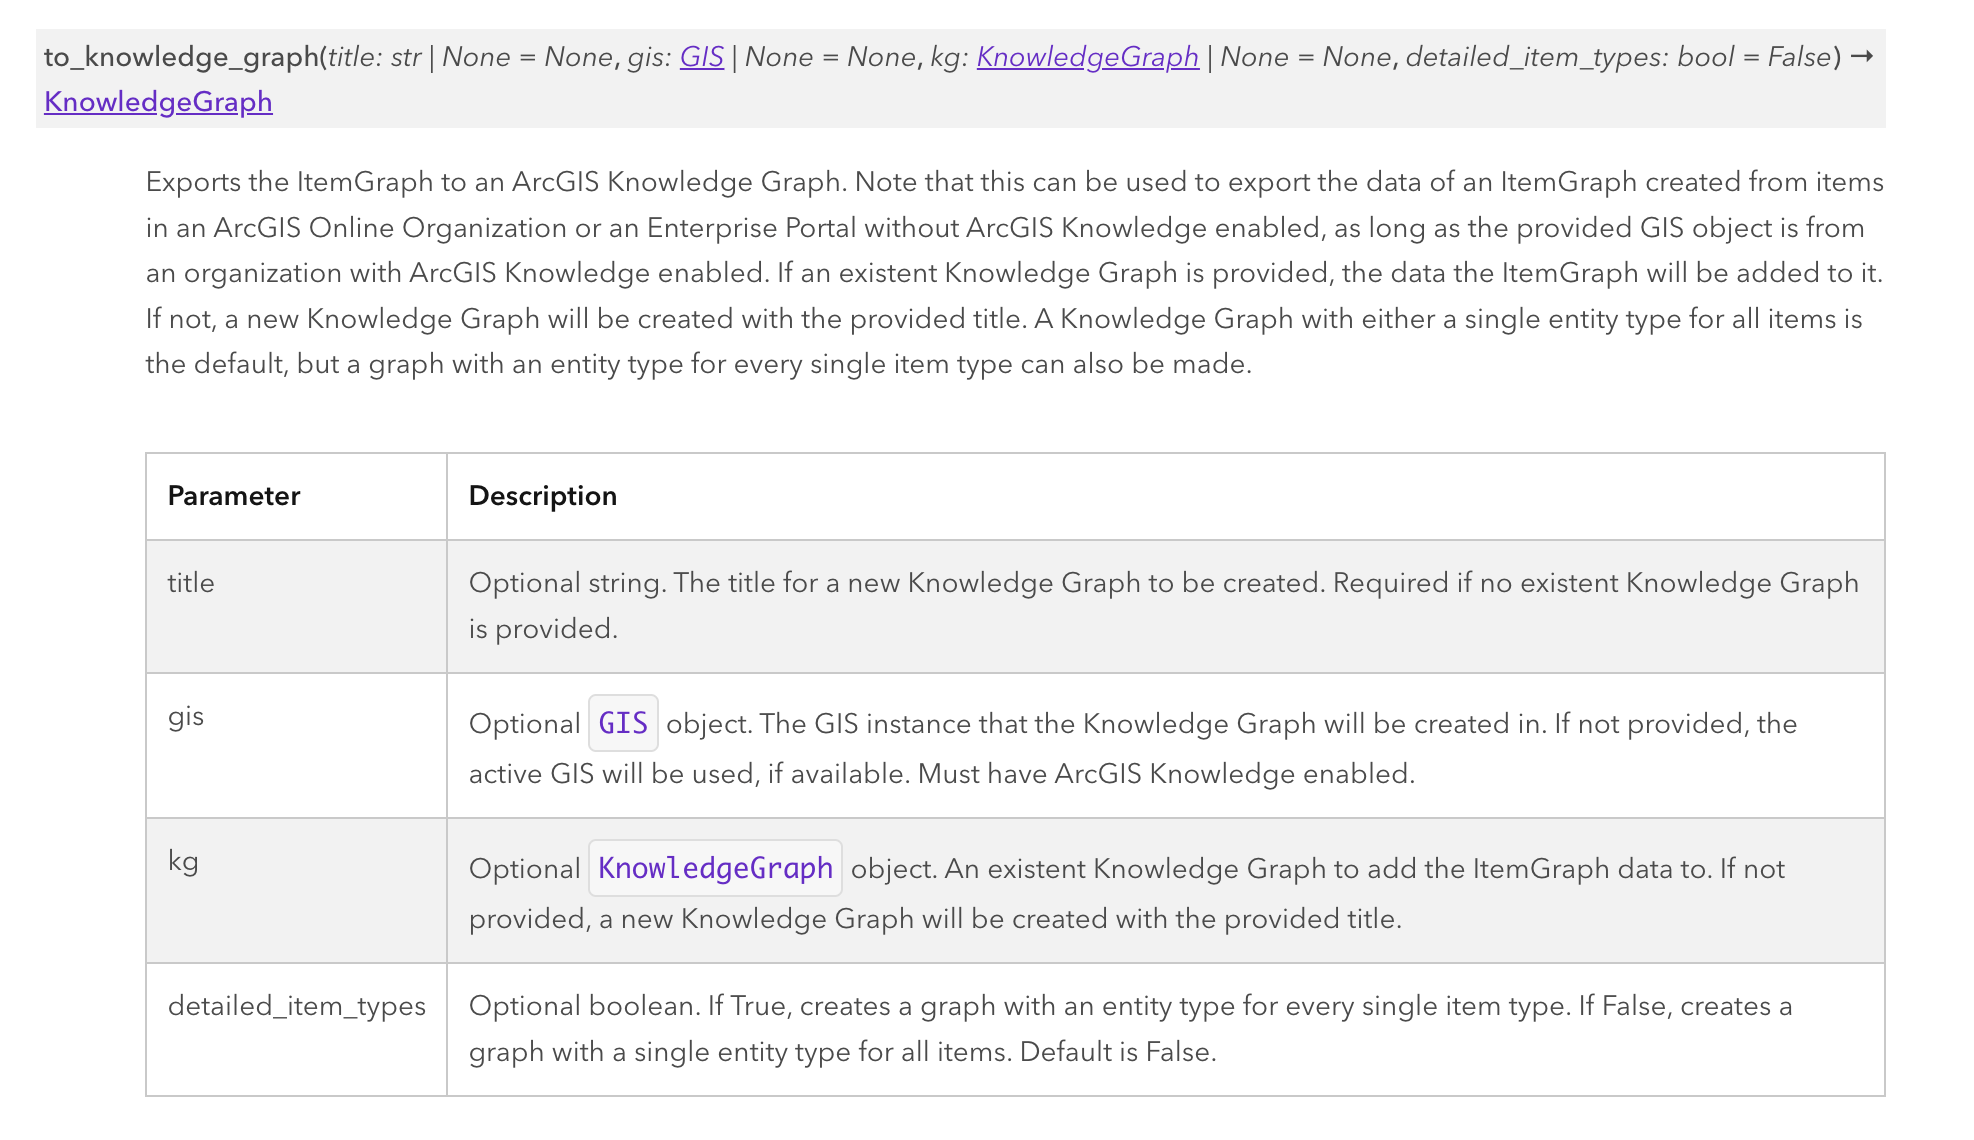
The function, at its simplest, requires one of two arguments: either the title of a new Knowledge Graph (`title`), or a [`KnowledgeGraph`](https://developers.arcgis.com/python/latest/api-reference/arcgis.graph.html#arcgis.graph.KnowledgeGraph) object corresponding to an existent graph derived from an `ItemGraph` (`kg`).

The `gis` argument dictates the ArcGIS Enterprise organization where a new Knowledge Service is created, and is only necessary if your `ItemGraph` was constructed from items in an organization without ArcGIS Knowledge enabled. If your `ItemGraph`'s `.gis` property is a Knowledge-enabled organization, then omitting this argument will result in a new Knowledge Service being created there by default.

One important thing to note is that the presence of the `kg` argument means that no new Knowledge Service will be created, and thus the `title` argument and `gis` argument become irrelevant if `kg` exists. Passing in an existent graph will result in the contents of the `ItemGraph` being added to the graph, making it useful for updating a graph over time.

The final argument above, `detailed_item_types`, dictates the data model of the Knowledge Graph. If `True`, the items in the graph will be added to the graph as Entity types corresponding to their item type. For example, if `True`, a Web Experience item is added as a `webExperience` entity, and a Web Map is added as a `webMap` entity. If `False`, they're both added as `portalItem` entities, a generic node type covering all item types.

In upcoming versions of the ArcGIS API for Python, additional parameters for capturing item information in the Knowledge Graph will be added, such as enabling detailed service types and including different item metadata properties on the entities.

## Usage Examples

### Creating a new Knowledge Graph
We'll start with the most simple use case- creating an ItemGraph on a Knowledge-enabled Enterprise and quickly publishing it to a Knowledge Graph.

In [2]:
# start by making the necessary imports
from arcgis.apps.itemgraph import create_dependency_graph
from arcgis.gis import GIS

In [3]:
# log into our org and grab our root nodes
kg_gis = GIS(profile = "your_enterprise_profile")
experience = kg_gis.content.get("e8f3337e8bde4deca08cdffedd4538be")
webmap = kg_gis.content.get("27789d55185c47b6b9b9e21e3a17573e")

In [4]:
# create our graph- this is all items our root nodes need to exist
graph = create_dependency_graph(kg_gis, [experience, webmap])
graph.all_items()

[ItemNode(id: e8f3337e8bde4deca08cdffedd4538be, item: Oceanic Experience),
 ItemNode(id: d099b5e5759f46da95102b06237f187a, item: Ugly Map),
 ItemNode(id: a6551b13d2154a84b41bcccff95eaec1, item: CA/OR Airports),
 ItemNode(id: 8390292e57bb498bbdf6c74e94e5cefa, item: CA/OR Airports),
 ItemNode(id: de26a3cf4cc9451298ea173c4b324736, item: World Street Map),
 ItemNode(id: 27789d55185c47b6b9b9e21e3a17573e, item: Map that should totally work),
 ItemNode(id: ab285e99a97f4d6b83ead1d9e76e52a0, item: Read-Only CA/OR Airports),
 ItemNode(id: 5282612d2cd64642845e02560b7f66f1, item: Read-Only CA/OR Airports),
 ItemNode(id: 999662a9b5154368958376b6b1832bc6, item: polygons),
 ItemNode(id: c5b0d2ac8a744f4b95b02ff07a1e5390, item: polygons),
 ItemNode(id: 273bf8d5c8ac400183fc24e109d20bcf, item: Community)]

In [7]:
# we can quickly convert it to a Knowledge Graph, all we need is to give it a name
kg = graph.to_knowledge_graph("Basic_KG")
kg

In [24]:
# look for it in your org's GUI, or retrieve it this way
kg_id = kg.properties['serviceItemId']
kg_gis.content.get(kg_id)

<Item title:"Basic_KG" type:Knowledge Graph owner:publisher2>

And it's as easy as that! We can look at the resulting graph in Knowledge Studio. Notice that all of our items from our `graph.all_items()` call are there, and they're all entities of type `portalItem`.

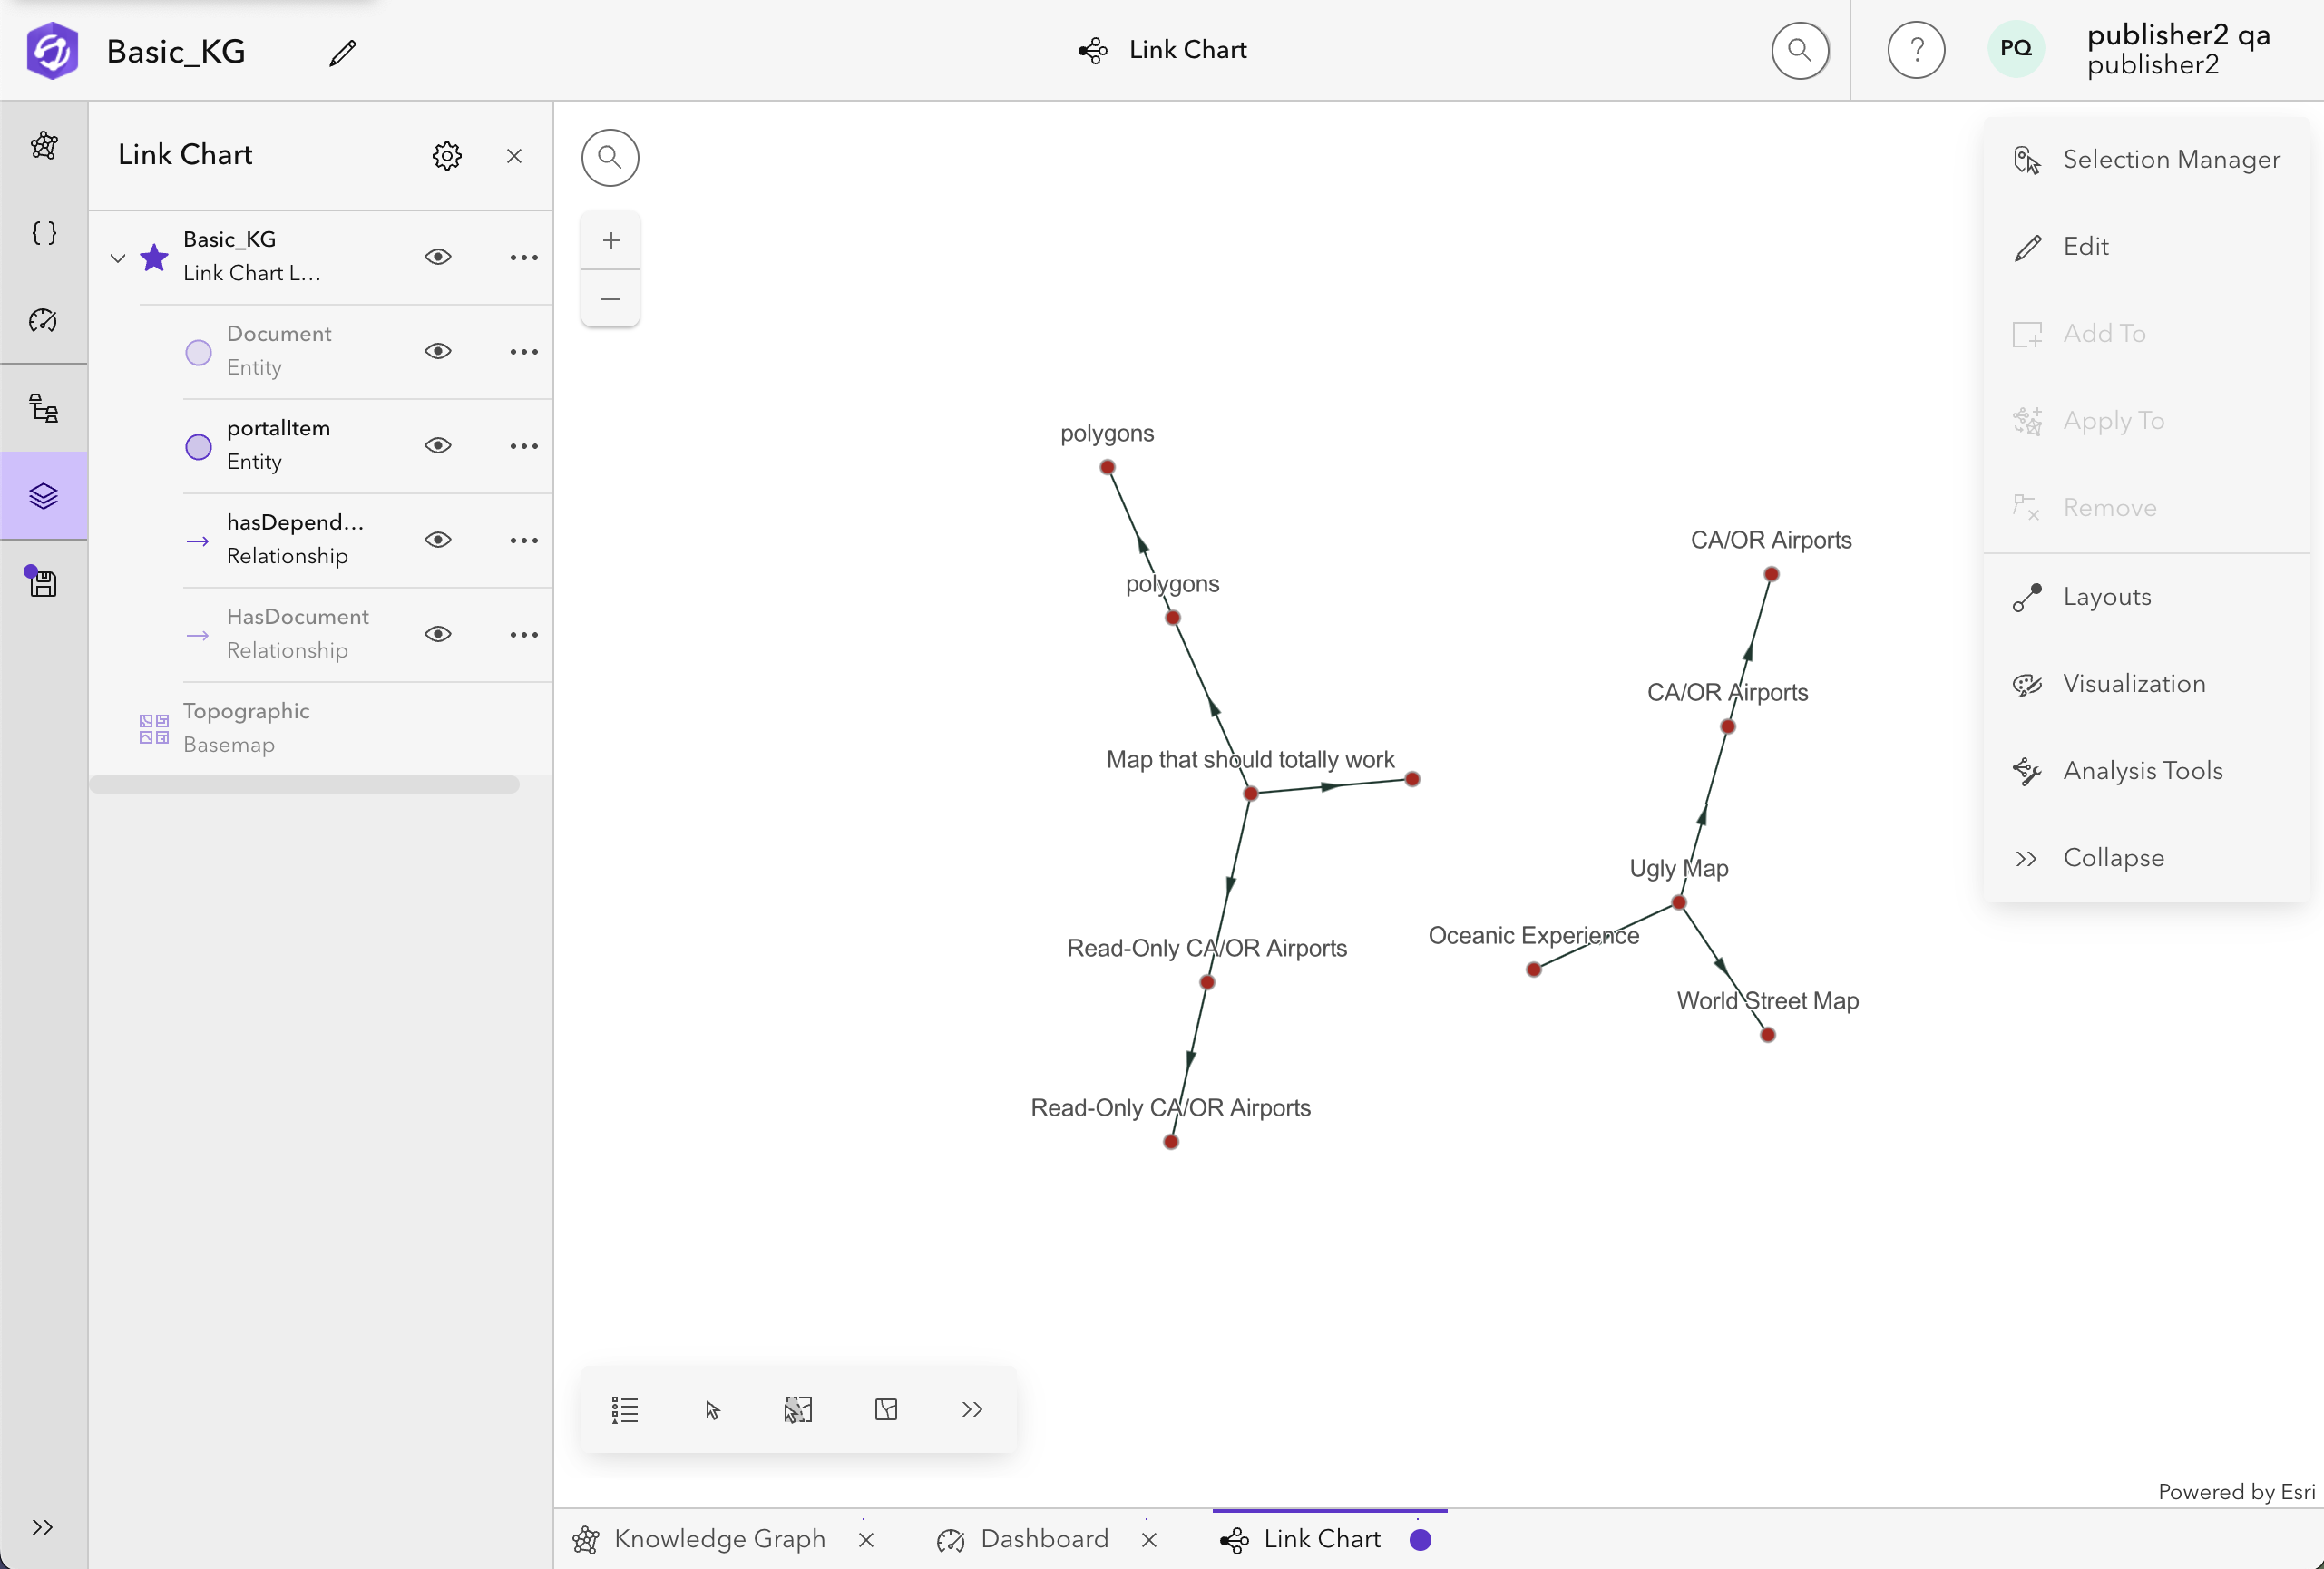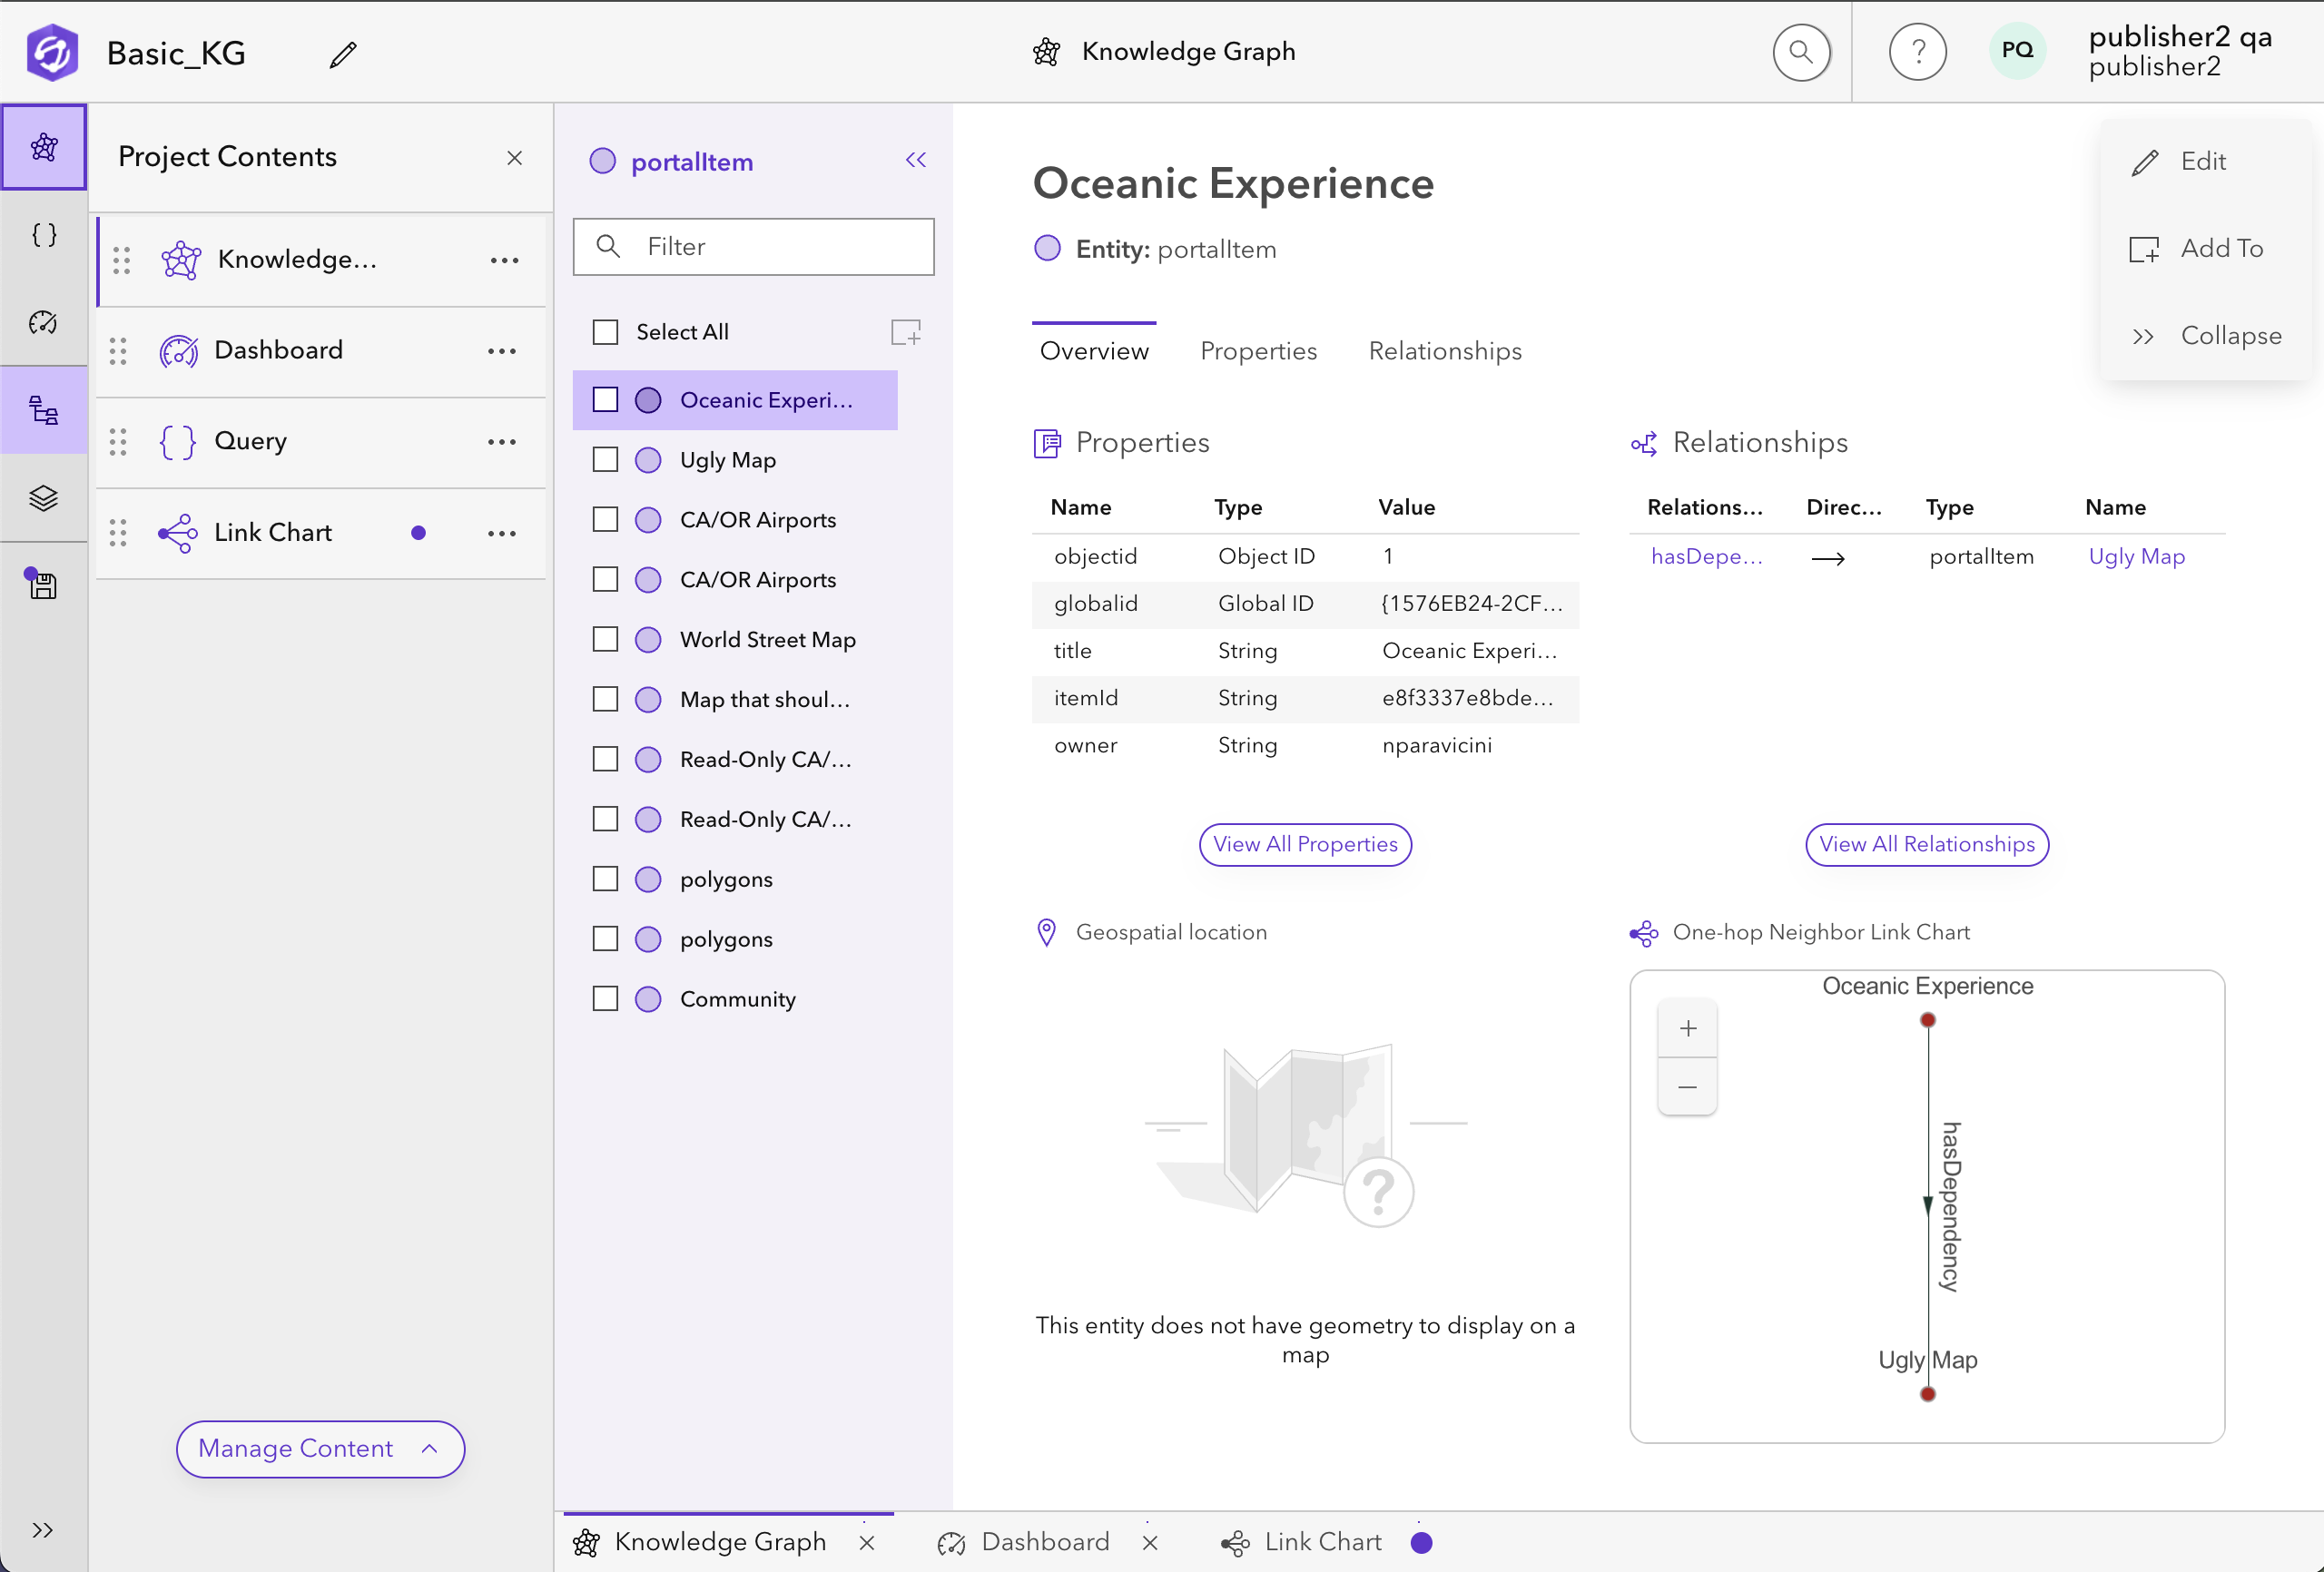

### Adding to an existing Knowledge Graph

Say we want to add more items to the graph we just made- all we have to do is create a new `ItemGraph`, and then reference our KG object in the method call.

In [14]:
# create another ItemGraph
storymap = kg_gis.content.get("0e28eb3472854ff6a6831aa3769a1fda")
graph2 = create_dependency_graph(kg_gis, [storymap])

In [17]:
# look at what we should see
graph2.all_items()

[ItemNode(id: 0e28eb3472854ff6a6831aa3769a1fda, item: LimerickStoryMap),
 ItemNode(id: 4577da5d9eee45c99b7593b24cf9e911, item: SimpleWebMap),
 ItemNode(id: e68b2a6c31ea48b7b78a1d7acfa6247a, item: SimpleWebMap_MIL1)]

In [16]:
# add it to our Knowledge Graph
graph2.to_knowledge_graph(kg = kg)

Let's take a look at our graph now! We'll see our StoryMap and its dependencies in there too.

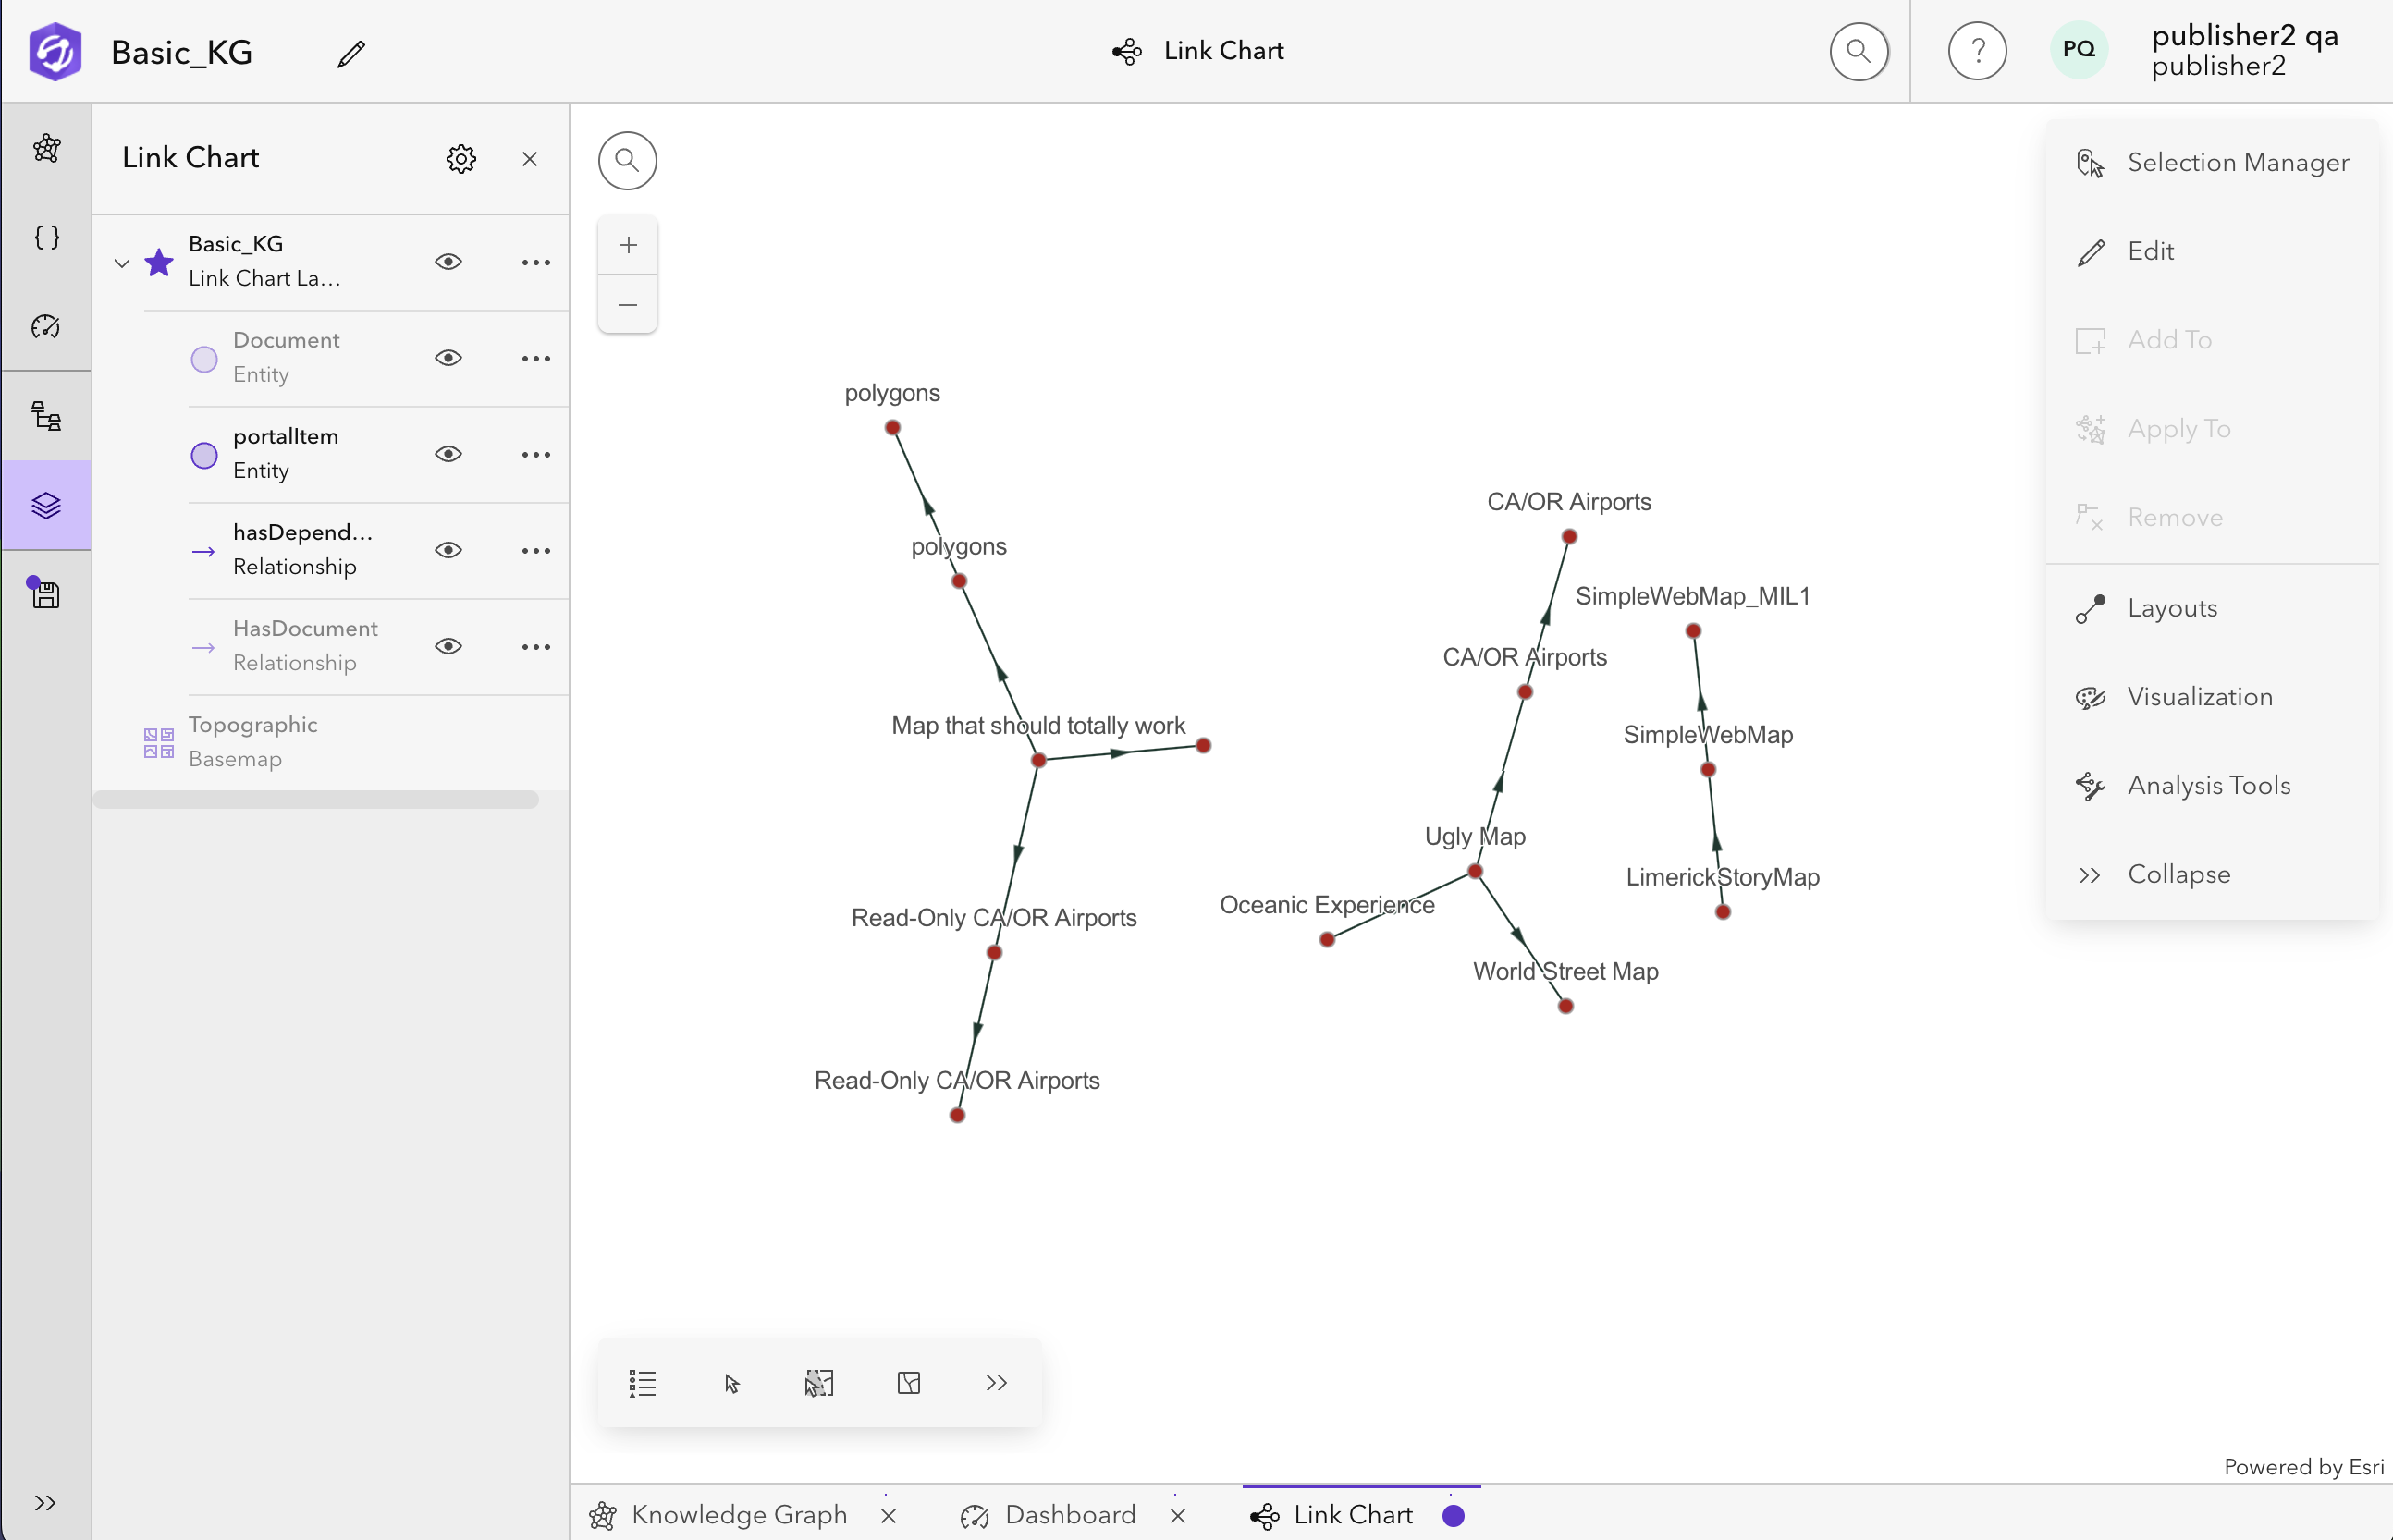

### Adding from a different organization and detailed item types

We're going to do 2 for 1 now- we'll show how you can display an `ItemGraph` created in a different organization, and show how we can make it more informative with detailed entity types in our new Knowledge Graph. We'll be working with an ArcGIS Online organization for this example.

In [19]:
# log into our online org and grab our root nodes
agol_gis = GIS(profile = "your_online_profile")
storymap = agol_gis.content.get("fd5801d2f66b43e1a20146d8761f758b")
survey = agol_gis.content.get("02d0702e1ef0468083f780791670c969")

In [20]:
# create our graph
graph = create_dependency_graph(agol_gis, [storymap, survey])
graph.all_items()

[ItemNode(id: fd5801d2f66b43e1a20146d8761f758b, item: Oh heavens),
 ItemNode(id: 7099b3c2e979415e975d00e58afed77e, item: Map that should totally work),
 ItemNode(id: 55c85385338d434ba1194d9b2c2a60c8, item: polygons),
 ItemNode(id: d3a24f71ee864118968fa24e572c6dc2, item: polygons),
 ItemNode(id: 273bf8d5c8ac400183fc24e109d20bcf, item: Community),
 ItemNode(id: baaf98d1695f47db8d5dc701c0e5f864, item: Read-Only CA/OR Airports),
 ItemNode(id: 865ec0112fde477788c4f51c4a7baae6, item: clone map different layer id),
 ItemNode(id: 2113d04eade0432784e8edd336193e68, item: CA/OR Airports),
 ItemNode(id: 35983e54e61a40b8ac03148e197452ac, item: PLACES: Arthritis),
 ItemNode(id: 02d0702e1ef0468083f780791670c969, item: San Diego Parrot Sightings),
 ItemNode(id: a7192e06cfb446e1bab59849285e1038, item: San Diego Parrot Sightings_results),
 ItemNode(id: 41dd3cca32914cc7ae8fd3a727f44e17, item: San Diego Parrot Sightings),
 ItemNode(id: d818128edbab44099238bc44e4bf2df0, item: summary_individual_temp),
 Ite

In [22]:
# when we call the function, specify the Knowledge-enabled Enterprise as the gis, and enable detailed types
detailed_kg = graph.to_knowledge_graph(title = "Detailed_KG", gis = kg_gis, detailed_item_types = True)
detailed_kg

In [23]:
# we can see all of the entity types in our new knowledge graph
for entity_type in detailed_kg.datamodel["entity_types"]:
    print(entity_type)

featureService
form
storymap
microsoftWord
webMap
Document
vectorTileService
shapefile


And we can see the result of this below! All of the entity types are present when looking in Knowledge Studio.

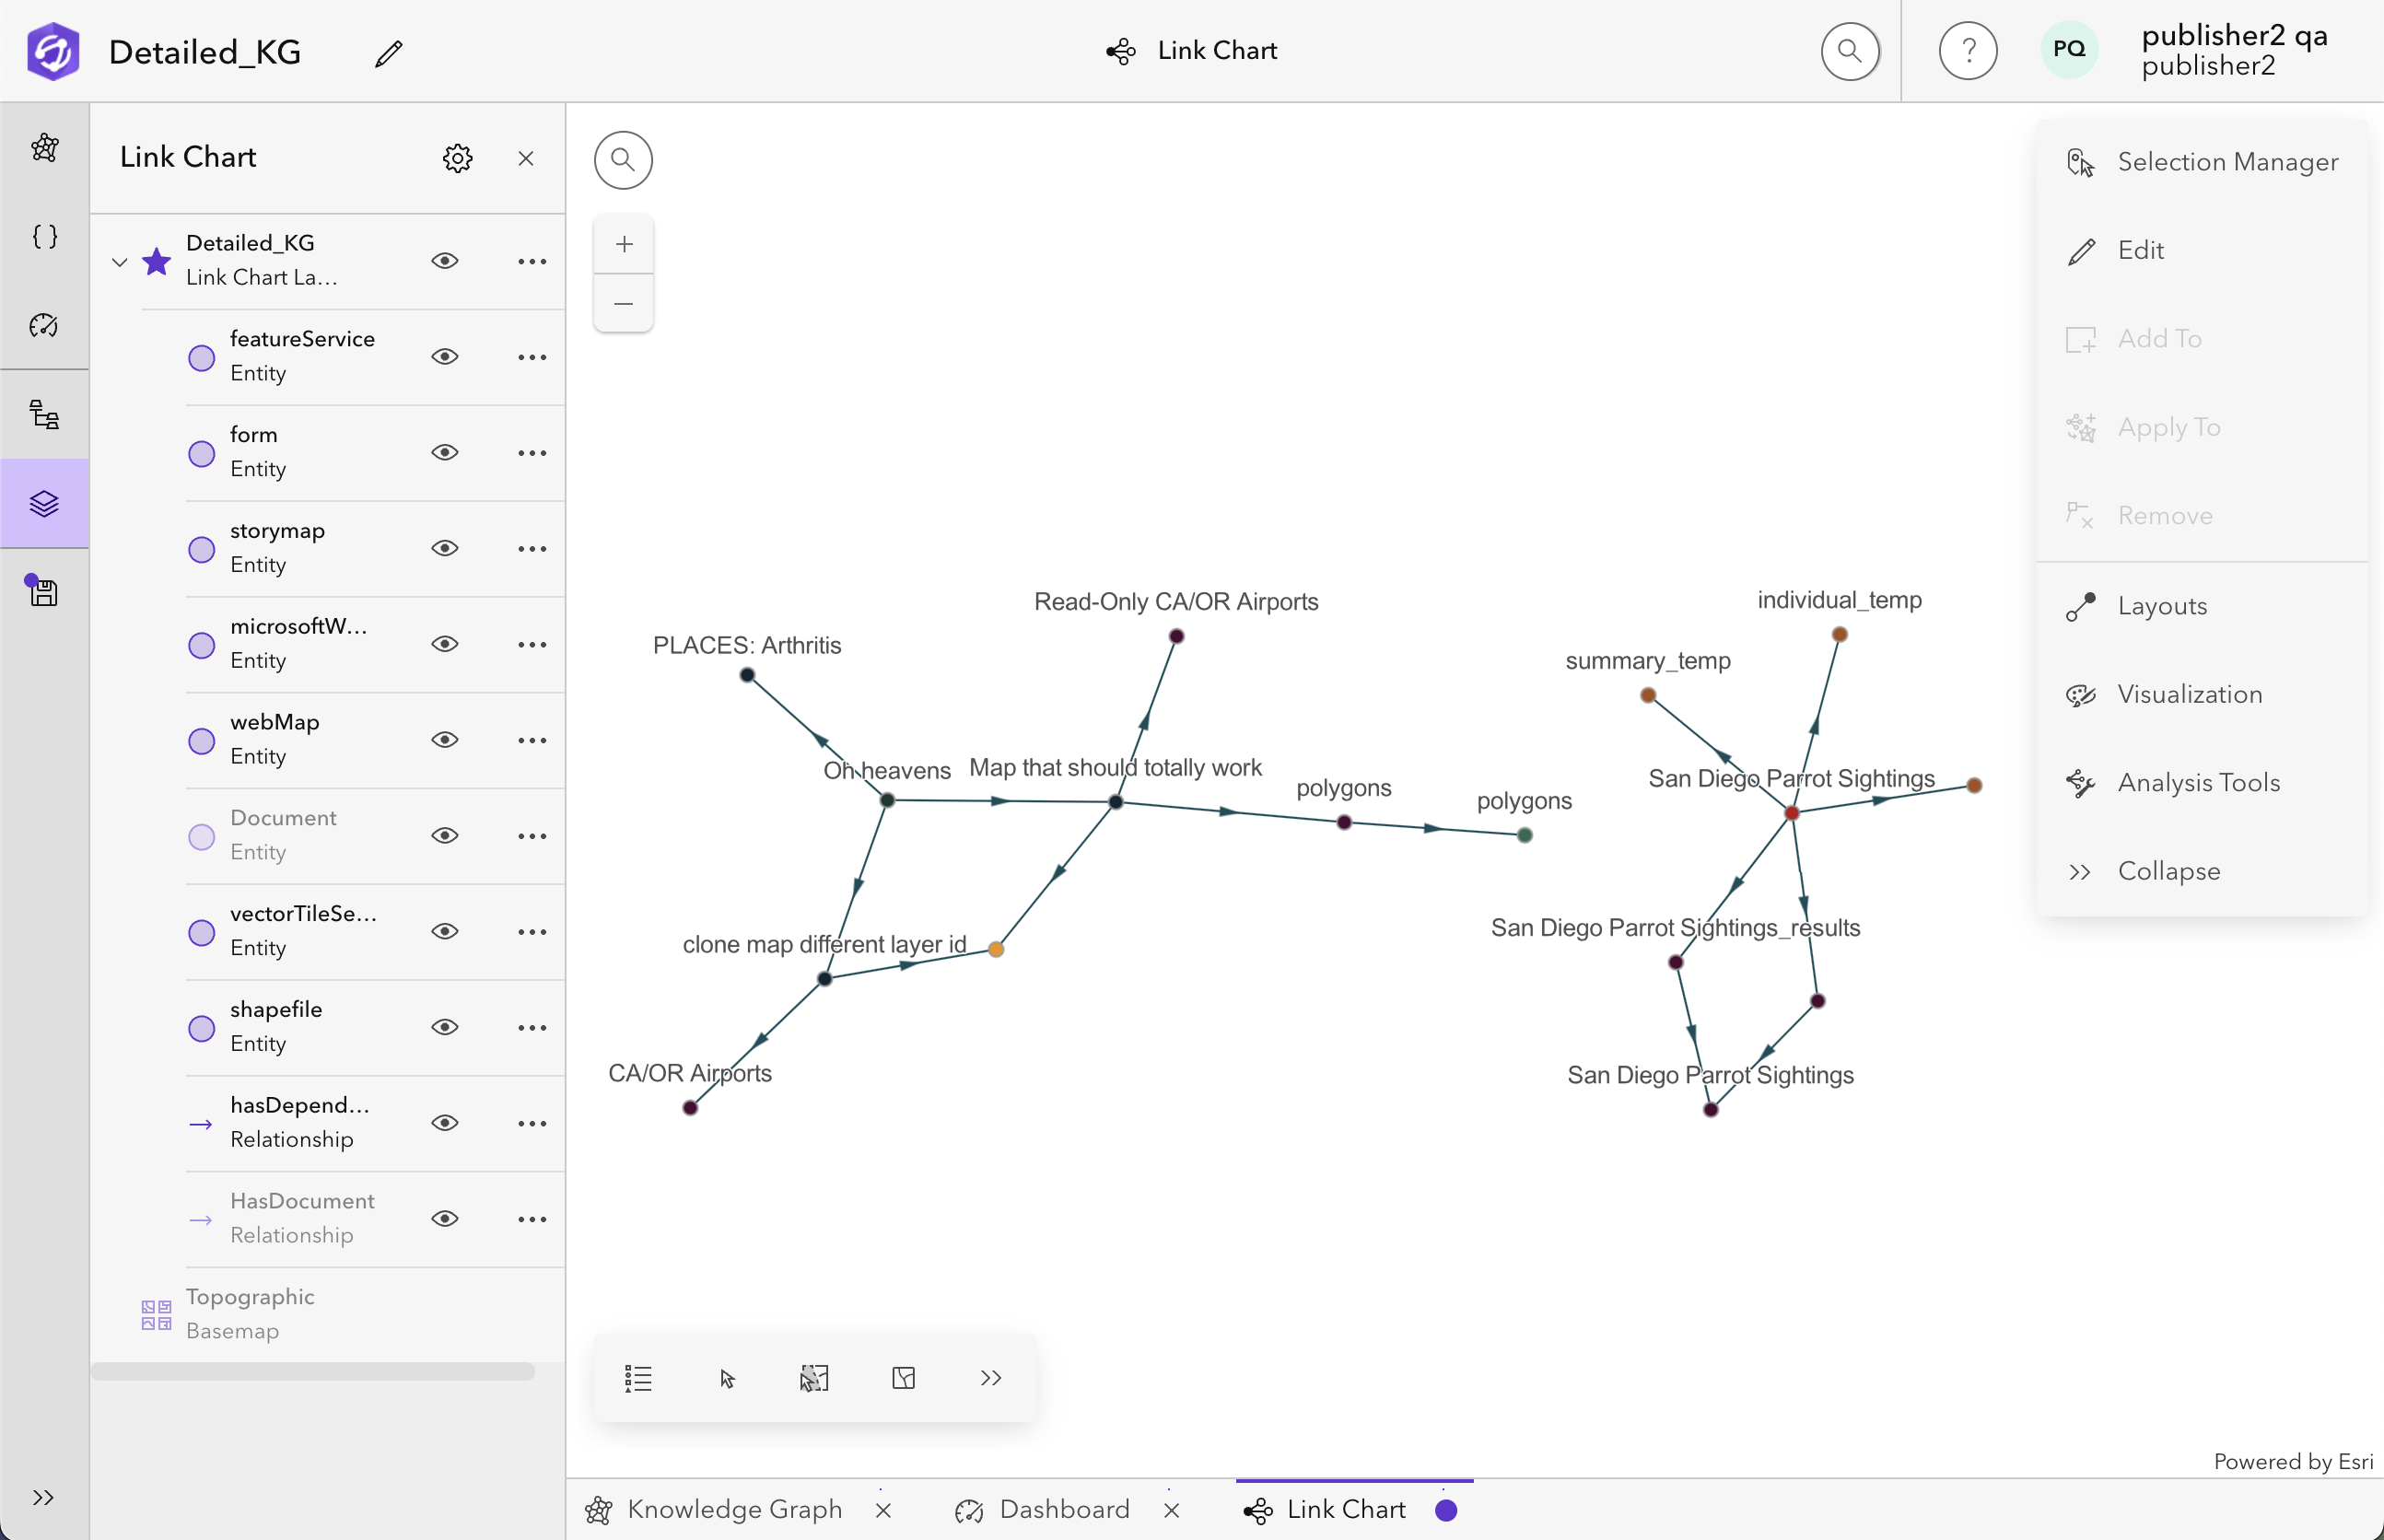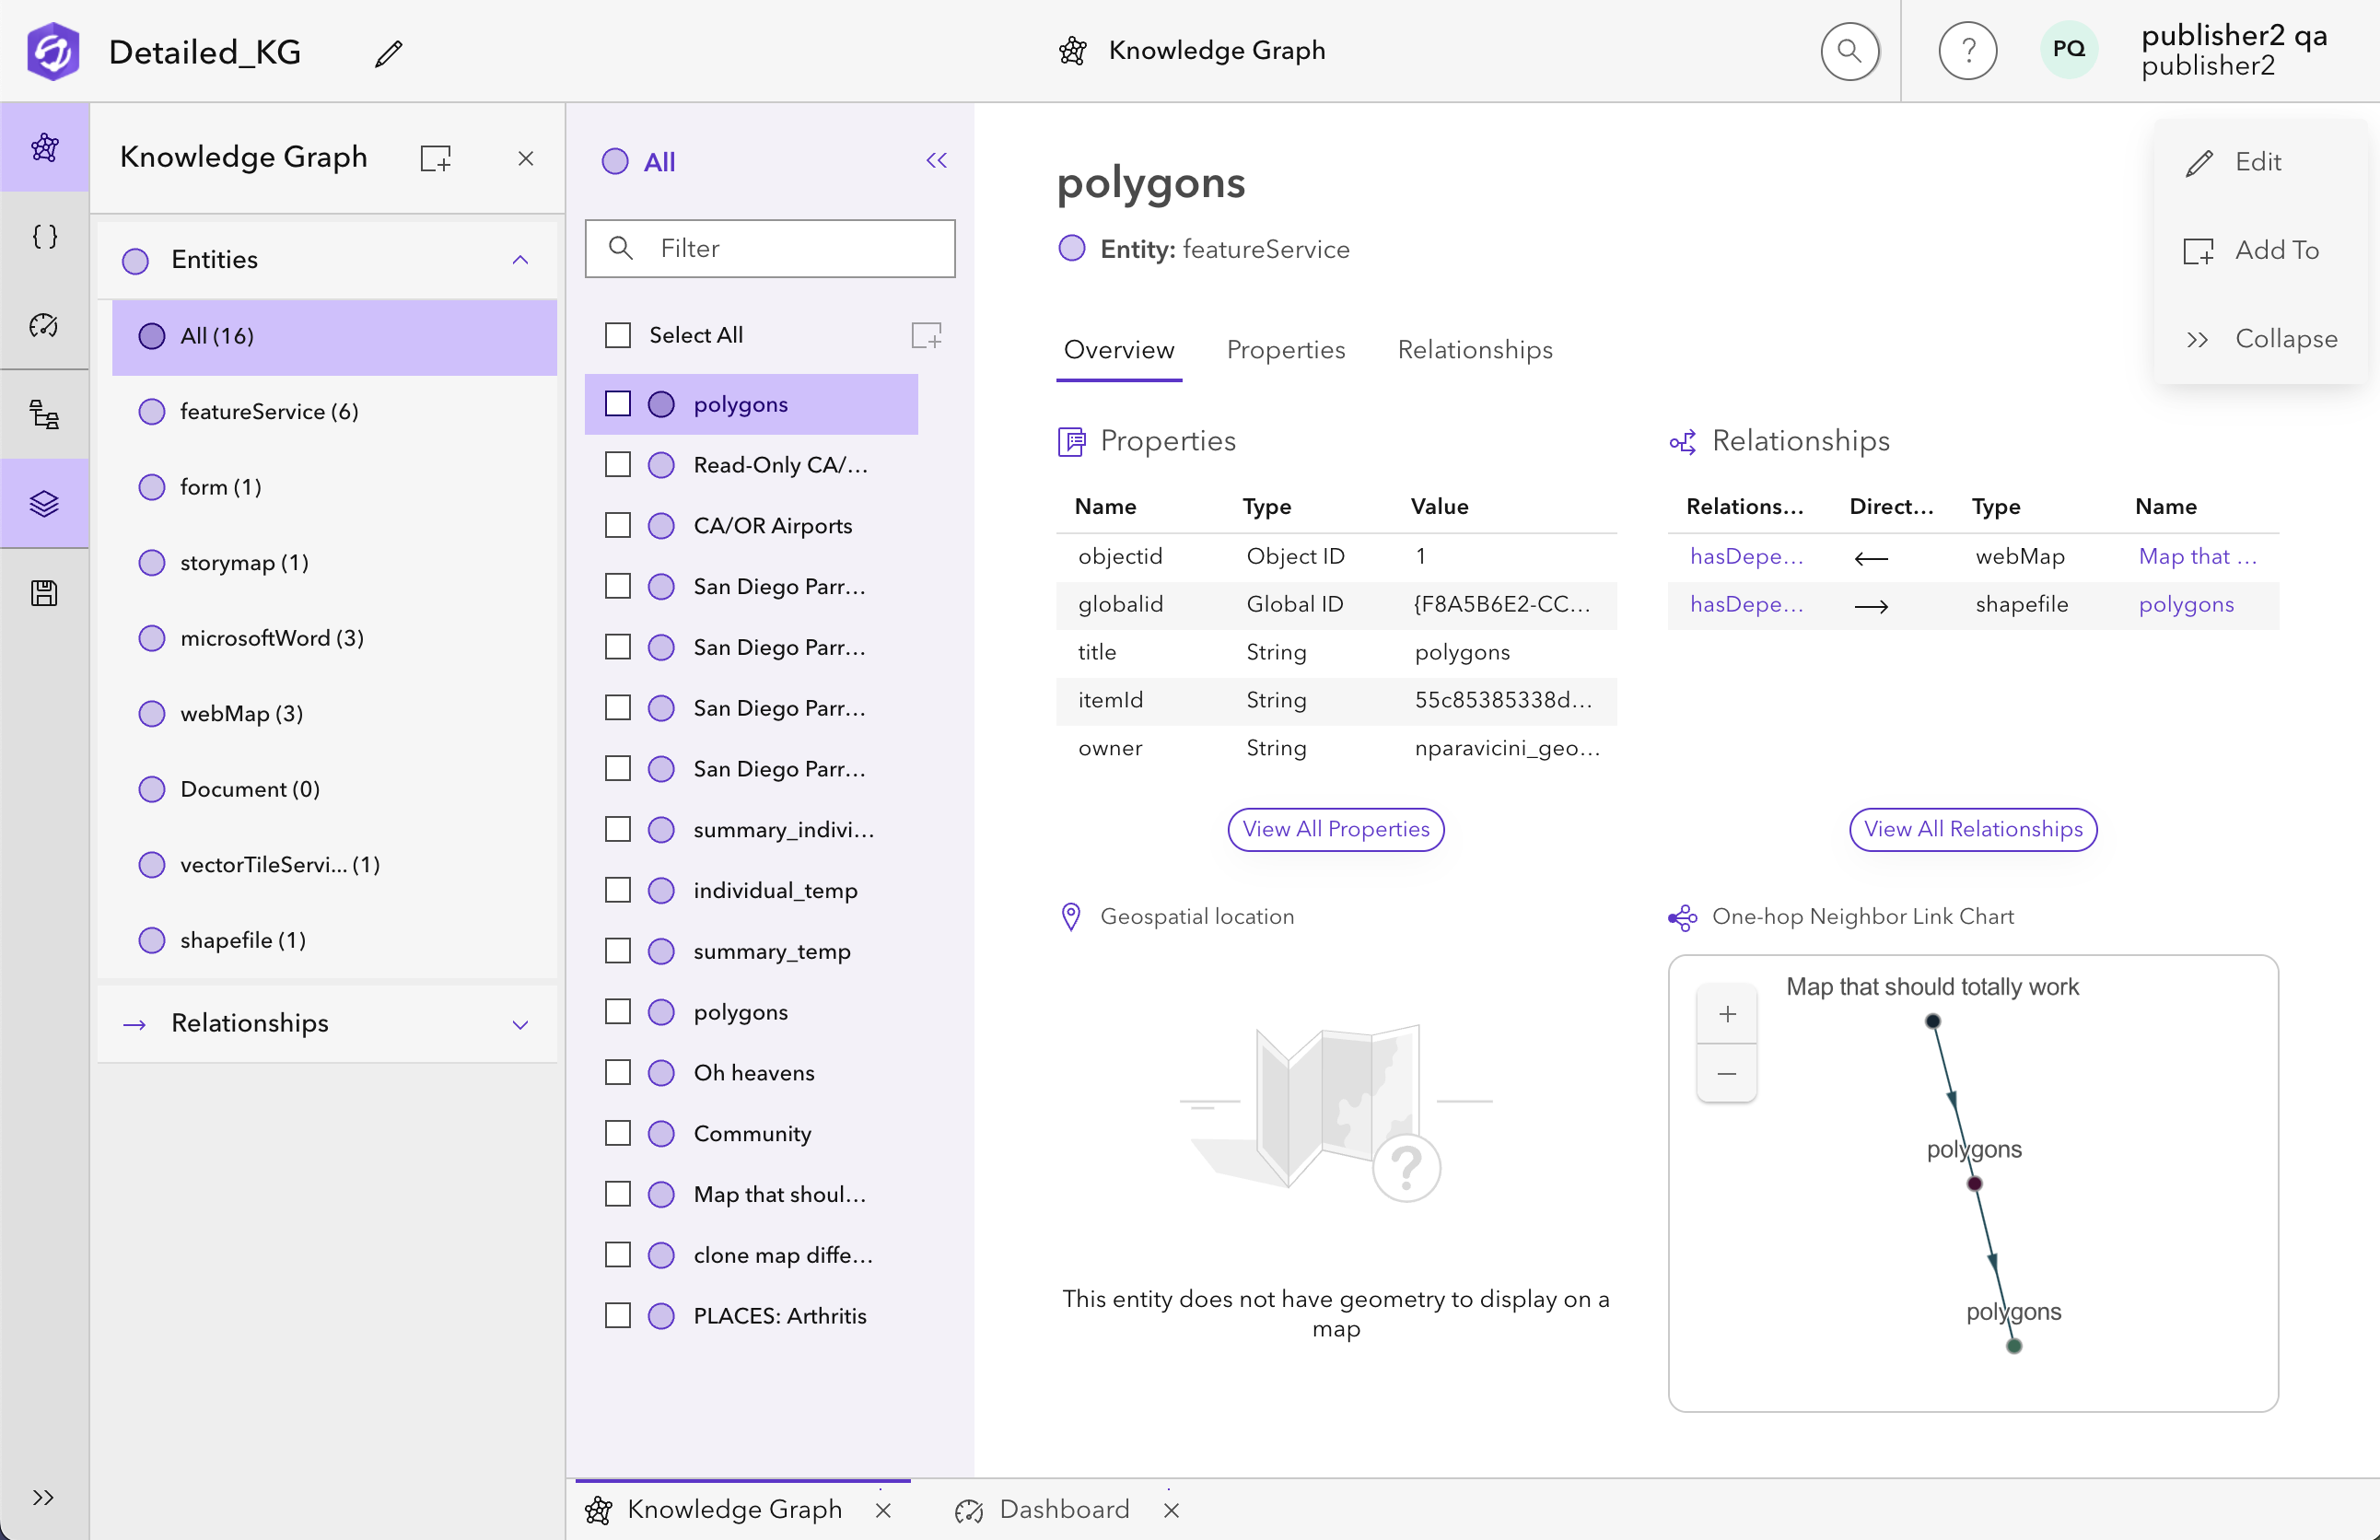